In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error


import sys
sys.path.append("..")

from utils.preprocessing import preprocessing_completo
from utils.config import PATH_RAD_MUNICIPIOS, PATH_PIB_MONTERREY

_,_,mont_rad_pib = preprocessing_completo("monterrey", path_radianza = PATH_RAD_MUNICIPIOS, path_pib = PATH_PIB_MONTERREY)

mont_rad_pib["log_pib_mun_trend"] = np.log(mont_rad_pib["pib_mun_trend"])
medidas = mont_rad_pib.drop(["quarter", "fecha", "municipio", "pib_mun_desestacionalizado", "pib_mun_trend", "log_pib_mun_trend"],axis = 1).columns.tolist()
for col in medidas:
    mont_rad_pib[col] = np.log(mont_rad_pib[col])


# Random Forest Regressor sin 'year'

,MSE,RMSE,MAE,MAPE,MSE_log,RMSE_log,MAE_log,MAPE_log
mean,0.001813,0.042119,0.033101,0.002686,0.000012,0.003418,0.002685,0.001069
std,0.000642,0.006991,0.002194,0.000176,0.000004,0.000573,0.000176,0.000070


RMSE forecast: 20992.662796
MSE forecast: 440691891.268533
MAE forecast: 20787.337332


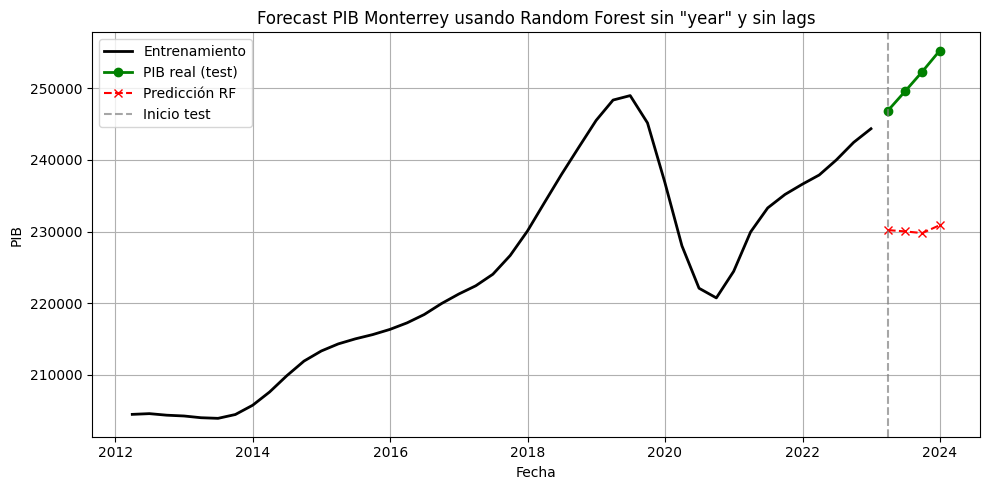

In [16]:
X = mont_rad_pib[medidas]
y = mont_rad_pib["log_pib_mun_trend"]

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=10)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    "MSE": [],
    "RMSE": [],
    "MAE": [],
    "MAPE": [],
    "MSE_log": [],
    "RMSE_log": [],
    "MAE_log": [],
    "MAPE_log": []
}

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test))
    
    # Calcular métricas en escala logarítmica
    y_test_log = np.log(y_test)
    y_pred_log = np.log(y_pred)
    
    mse_log = mean_squared_error(y_test_log, y_pred_log)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test_log, y_pred_log)
    mape_log = np.mean(np.abs((y_test_log - y_pred_log) / y_test_log))

    metrics["MSE"].append(mse)
    metrics["RMSE"].append(rmse)
    metrics["MAE"].append(mae)
    metrics["MAPE"].append(mape)
    metrics["MSE_log"].append(mse_log)
    metrics["RMSE_log"].append(rmse_log)
    metrics["MAE_log"].append(mae_log)
    metrics["MAPE_log"].append(mape_log)

metrics = pd.DataFrame(metrics)
metrics_summary = metrics.agg(["mean", "std"])
display(metrics_summary)

# -------- Adecuar forecast con Random Forest para que funcione --------

# Para el forecast, vamos a tomar los últimos periodos de cada municipio como test
# NOTA: Asegúrate de que df_processed, features y 'pib_mun', 'fecha' existen y son correctos.

# Selección de features correctas y consistentes
features = medidas  # Usamos las mismas features que arriba

# Si df_processed no existe, crearla a partir de mont_rad_pib para ejemplo Monterrey
# Para Monterrey solo hay un municipio, así que ajustamos el forecast para ese escenario:
df_processed = mont_rad_pib.copy()
df_processed["municipio_monterrey"] = 1  # Dummy fix por compatibilidad con ciclo original
municipios = ["monterrey"]

n_preds = 4

X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

# Para Monterrey, solo necesitamos filtrar y tomar los últimos n_preds como test
for mun in municipios:
    if f'municipio_{mun}' in df_processed.columns:
        col = f'municipio_{mun}'
        df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()
    else:
        df_mun = df_processed.sort_values('fecha').copy()

    if len(df_mun) <= n_preds:
        continue

    # Dividir en train/test
    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['pib_mun_trend'].iloc[:-n_preds].astype(float)  # usar trend o real, ajustar segun disponibilidad
    y_mun_test = df_mun['pib_mun_trend'].iloc[-n_preds:].astype(float)

    # Concatenar
    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])

# Entrenar modelo
rf_time = RandomForestRegressor(
    n_estimators=100,
    max_leaf_nodes=None,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42
)

rf_time.fit(X_train, y_train)
y_pred = rf_time.predict(X_test)

# Métricas forecast
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE forecast: {rmse:.6f}")
print(f"MSE forecast: {mse:.6f}")
print(f"MAE forecast: {mae:.6f}")

# Preparar datos para visualización
df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred

# Graficar el forecast para Monterrey
for m in municipios:
    if f'municipio_{m}' in df_test.columns:
        col = f'municipio_{m}'
        df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
        df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')
    else:
        df_mun_train = df_train.sort_values('fecha')
        df_mun_test = df_test.sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    plt.figure(figsize=(10, 5))

    # PIB real en train
    if not df_mun_train.empty:
        plt.plot(df_mun_train['fecha'], df_mun_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)

    # PIB real en test y predicciones
    if not df_mun_test.empty:
        plt.plot(df_mun_test['fecha'], df_mun_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2, marker='o')
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred'],
                 label='Predicción RF', color='red', linestyle='--', marker='x')
        plt.axvline(x=df_mun_test['fecha'].iloc[0], color='gray',
                   linestyle='--', alpha=0.7, label='Inicio test')

    plt.title(f'Forecast PIB Monterrey usando Random Forest sin "year" y sin lags')
    plt.xlabel('Fecha')
    plt.ylabel('log(PIB)' if y_train.name == "log_pib_mun_trend" else "PIB")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


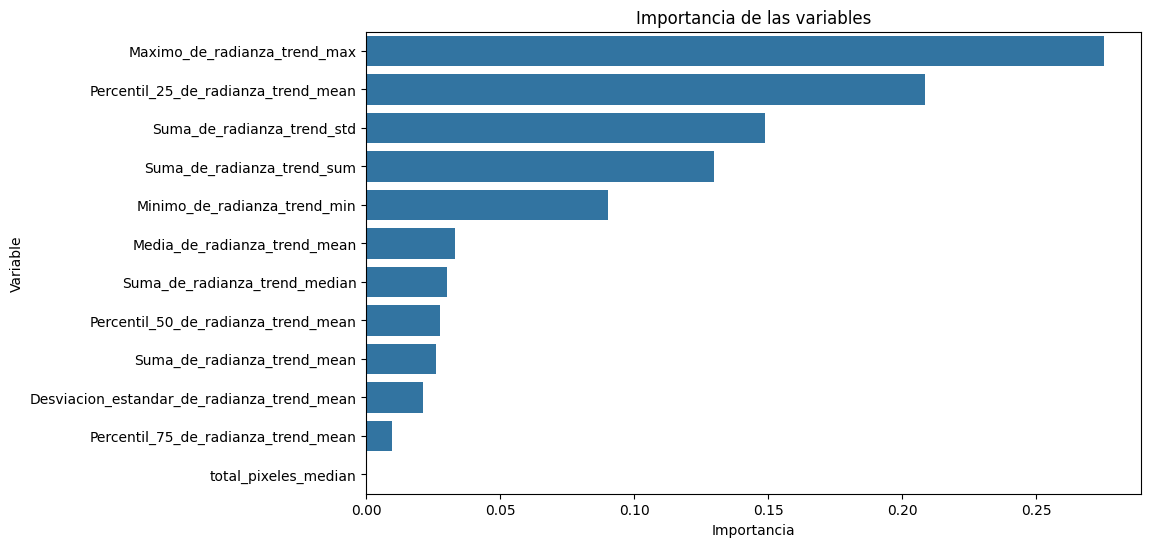

In [17]:
importance = rf.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by = "Importance", ascending = False)
importance = rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, orient="h")
plt.title("Importancia de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


# Random Forest Regressor con 'Year'

,MSE,RMSE,MAE,MAPE,MSE_log,RMSE_log,MAE_log,MAPE_log
mean,0.000515,0.021866,0.017820,0.001444,0.000003,0.001772,0.001445,0.000575
std,0.000354,0.006809,0.005636,0.000454,0.000002,0.000549,0.000455,0.000181


RMSE forecast: 6166.059946
MSE forecast: 38020295.251819
MAE forecast: 5263.518326


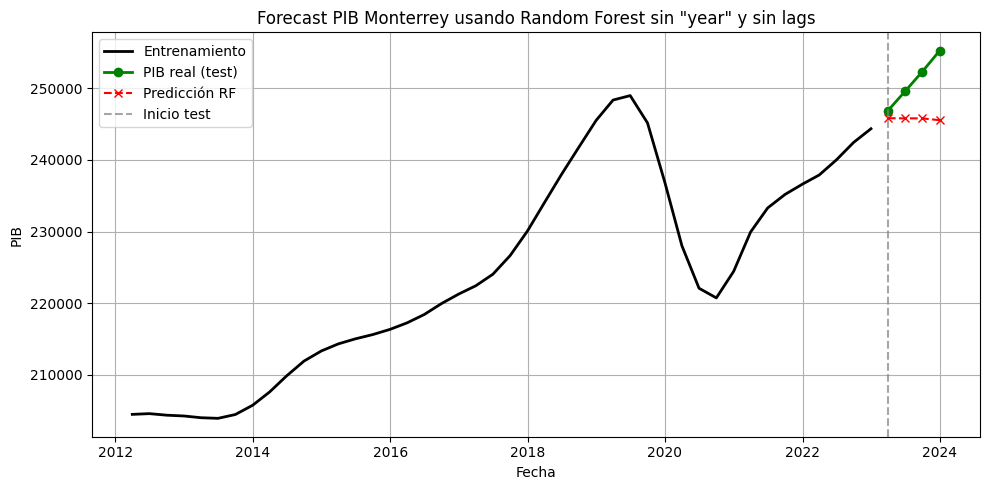

In [ ]:
mont_rad_pib["year"] = mont_rad_pib["fecha"].dt.year
medidas.append("year")

X = mont_rad_pib[medidas]
y = mont_rad_pib["log_pib_mun_trend"]

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=10)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    "MSE": [],
    "RMSE": [],
    "MAE": [],
    "MAPE": [],
    "MSE_log": [],
    "RMSE_log": [],
    "MAE_log": [],
    "MAPE_log": []
}

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test))
    
    # Calcular métricas en escala logarítmica
    y_test_log = np.log(y_test)
    y_pred_log = np.log(y_pred)
    
    mse_log = mean_squared_error(y_test_log, y_pred_log)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test_log, y_pred_log)
    mape_log = np.mean(np.abs((y_test_log - y_pred_log) / y_test_log))

    metrics["MSE"].append(mse)
    metrics["RMSE"].append(rmse)
    metrics["MAE"].append(mae)
    metrics["MAPE"].append(mape)
    metrics["MSE_log"].append(mse_log)
    metrics["RMSE_log"].append(rmse_log)
    metrics["MAE_log"].append(mae_log)
    metrics["MAPE_log"].append(mape_log)

metrics = pd.DataFrame(metrics)
metrics_summary = metrics.agg(["mean", "std"])
display(metrics_summary)

# -------- Adecuar forecast con Random Forest para que funcione --------

# Para el forecast, vamos a tomar los últimos periodos de cada municipio como test
# NOTA: Asegúrate de que df_processed, features y 'pib_mun', 'fecha' existen y son correctos.

# Selección de features correctas y consistentes
features = medidas  # Usamos las mismas features que arriba

# Si df_processed no existe, crearla a partir de mont_rad_pib para ejemplo Monterrey
# Para Monterrey solo hay un municipio, así que ajustamos el forecast para ese escenario:
df_processed = mont_rad_pib.copy()
df_processed["municipio_monterrey"] = 1  # Dummy fix por compatibilidad con ciclo original
municipios = ["monterrey"]

n_preds = 4

X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

# Para Monterrey, solo necesitamos filtrar y tomar los últimos n_preds como test
for mun in municipios:
    if f'municipio_{mun}' in df_processed.columns:
        col = f'municipio_{mun}'
        df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()
    else:
        df_mun = df_processed.sort_values('fecha').copy()

    if len(df_mun) <= n_preds:
        continue

    # Dividir en train/test
    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['pib_mun_trend'].iloc[:-n_preds].astype(float)  # usar trend o real, ajustar segun disponibilidad
    y_mun_test = df_mun['pib_mun_trend'].iloc[-n_preds:].astype(float)

    # Concatenar
    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])

# Entrenar modelo
rf_time = RandomForestRegressor(
    n_estimators=100,
    max_leaf_nodes=None,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42
)

rf_time.fit(X_train, y_train)
y_pred = rf_time.predict(X_test)

# Métricas forecast
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE forecast: {rmse:.6f}")
print(f"MSE forecast: {mse:.6f}")
print(f"MAE forecast: {mae:.6f}")

# Preparar datos para visualización
df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred

# Graficar el forecast para Monterrey
for m in municipios:
    if f'municipio_{m}' in df_test.columns:
        col = f'municipio_{m}'
        df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
        df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')
    else:
        df_mun_train = df_train.sort_values('fecha')
        df_mun_test = df_test.sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    plt.figure(figsize=(10, 5))

    # PIB real en train
    if not df_mun_train.empty:
        plt.plot(df_mun_train['fecha'], df_mun_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)

    # PIB real en test y predicciones
    if not df_mun_test.empty:
        plt.plot(df_mun_test['fecha'], df_mun_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2, marker='o')
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred'],
                 label='Predicción RF', color='red', linestyle='--', marker='x')
        plt.axvline(x=df_mun_test['fecha'].iloc[0], color='gray',
                   linestyle='--', alpha=0.7, label='Inicio test')

    plt.title(f'Forecast PIB Monterrey usando Random Forest con "year" y sin lags')
    plt.xlabel('Fecha')
    plt.ylabel('log(PIB)' if y_train.name == "log_pib_mun_trend" else "PIB")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


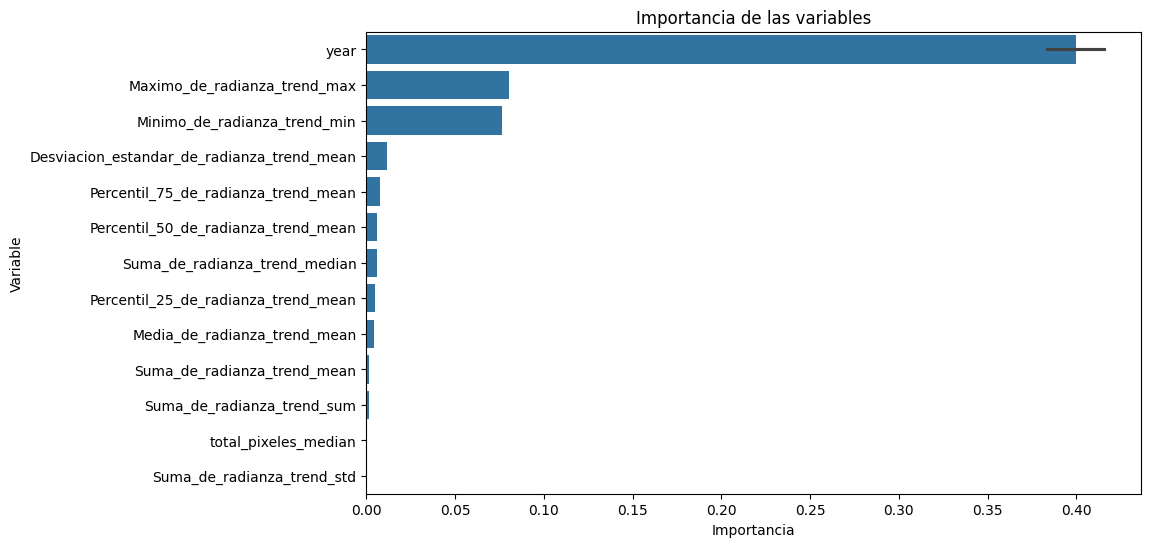

In [20]:
importance = rf.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by = "Importance", ascending = False)
importance = rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, orient="h")
plt.title("Importancia de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()
